# Wafer Anomaly Detection with PatchCore — Improved (4060 Laptop Safe)

**Key improvements over the baseline:**
1. **WideResNet-50-2 backbone** instead of ResNet18
2. **ImageNet normalization** — maps wafer values to pseudo-RGB properly
3. **3×3 neighborhood avg-pooling** on feature maps (original PatchCore design)
4. **k-NN scoring (k=3)** instead of 1-NN
5. **Memory-safe coreset**: random pre-filter on GPU → greedy coreset with chunked distance
6. **More test defects** (2000, stratified by class)
7. **FPR-constrained threshold** — fix specificity ≥ 95%, maximize recall

**OOM fixes vs previous version:**
- Patches are subsampled on-the-fly during extraction (never hold 39M patches anywhere)
- Greedy coreset uses chunked distance computation — no N×N matrix ever allocated
- `BATCH_SIZE=32` default (safe for WRN-50 on 8 GB)
- `SCORE_CHUNK=256` limits peak VRAM during nearest-neighbour search

In [28]:
import os, gc, json, random, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchvision.models import wide_resnet50_2, Wide_ResNet50_2_Weights
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')
    # Reduces fragmentation on consumer laptop GPUs
    os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

print('Device:', DEVICE)
if USE_CUDA:
    print('GPU:  ', torch.cuda.get_device_name(0))
    print(f'VRAM:  {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU:   NVIDIA GeForce RTX 4060 Laptop GPU
VRAM:  8.6 GB


In [29]:
# ── Configuration ─────────────────────────────────────────────────────────────
DATA_PATH  = '../data/raw/LSWMD.pkl'
IMAGE_SIZE = 224           # wafer maps are low-res; 64 is enough and fast

NUM_WORKERS = 0
PIN_MEMORY  = False
BATCH_SIZE  = 32 if USE_CUDA else 16   # conservative for WRN-50 on 8 GB

TRAIN_NORMAL_N    = 50_000
TEST_NORMAL_N     = 5_000
TEST_DEFECT_N     = 2_000
DEFECTS_PER_CLASS = 250

# ── Coreset / memory-bank settings ────────────────────────────────────────────
# CORESET_POOL: how many patches we keep after on-the-fly random filtering.
# These all live on GPU during the greedy coreset step.
# 150k × 1536 × fp32 ≈ 925 MB VRAM — safe on 8 GB with WRN-50 unloaded.
MEMORY_BANK_FINAL = 50_000    # final bank size
CORESET_POOL      = 150_000   # random pre-filter; keep << total raw patches

SCORE_CHUNK = 256 if USE_CUDA else 128
KNN_K       = 5
USE_AMP     = USE_CUDA

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

TARGET_SPECIFICITY = 0.95    # fix FPR ≤ 5%, then maximise recall

ARTIFACT_DIR        = '../artifacts/x64/patchcore_improved'
MODEL_EXPORT_PATH   = os.path.join(ARTIFACT_DIR, 'patchcore_model.pt')
METRICS_EXPORT_PATH = os.path.join(ARTIFACT_DIR, 'evaluation_metrics.json')
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f'batch={BATCH_SIZE}, img_size={IMAGE_SIZE}')
print(f'pool={CORESET_POOL}, bank={MEMORY_BANK_FINAL}, chunk={SCORE_CHUNK}, k={KNN_K}')
print('Artifacts ->', ARTIFACT_DIR)

batch=32, img_size=224
pool=150000, bank=50000, chunk=256, k=5
Artifacts -> ../artifacts/x64/patchcore_improved


In [ ]:
# ── Load & clean ──────────────────────────────────────────────────────────────
df = pd.read_pickle(DATA_PATH)
print('Raw shape:', df.shape)

def parse_failure_label(value):
    if value is None: return 'unknown'
    if isinstance(value, float) and np.isnan(value): return 'unknown'
    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.array(value).reshape(-1)
        return 'unknown' if len(arr) == 0 else str(arr[0])
    return str(value)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).astype(str).str.strip()
invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

print('Labeled:', df.shape)
print('Normal:', len(normal_df), '  Defect:', len(defect_df))
print('\nDefect types:')
print(defect_df['failure_label'].value_counts())

In [ ]:
# ── Stratified split ──────────────────────────────────────────────────────────
if len(normal_df) < TRAIN_NORMAL_N + TEST_NORMAL_N:
    raise ValueError(f'Need {TRAIN_NORMAL_N+TEST_NORMAL_N} normals, have {len(normal_df)}')

rng = np.random.default_rng(SEED)
normal_shuf = normal_df.iloc[rng.permutation(len(normal_df))].reset_index(drop=True)
train_normal_df = normal_shuf.iloc[:TRAIN_NORMAL_N].copy()
test_normal_df  = normal_shuf.iloc[TRAIN_NORMAL_N:TRAIN_NORMAL_N + TEST_NORMAL_N].copy()

parts = [
    grp.sample(n=min(len(grp), DEFECTS_PER_CLASS), random_state=SEED)
    for _, grp in defect_df.groupby('failure_label')
]
test_defect_df = (
    pd.concat(parts)
    .sample(n=min(TEST_DEFECT_N, sum(len(p) for p in parts)), random_state=SEED)
    .reset_index(drop=True)
)

print('Train normal:', len(train_normal_df))
print('Test  normal:', len(test_normal_df))
print('Test  defect:', len(test_defect_df))
print(test_defect_df['failure_label'].value_counts())

Train normal: 50000
Test  normal: 5000
Test  defect: 1899
failure_label
Loc          250
Center       250
Edge-Loc     250
Donut        250
Scratch      250
Random       250
Edge-Ring    250
Near-full    149
Name: count, dtype: int64


In [ ]:
# ── Wafer map → ImageNet-normalised tensor ────────────────────────────────────
_mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
_std  = torch.tensor(IMAGENET_STD ).view(3, 1, 1)

def wafer_to_tensor(wafer_map, size=224):
    arr = np.clip(np.array(wafer_map, dtype=np.float32), 0, 2) / 2.0
    x   = torch.from_numpy(arr).unsqueeze(0).expand(3, -1, -1)
    x   = F.interpolate(x.unsqueeze(0), size=(size, size), mode='nearest').squeeze(0)
    return (x - _mean) / _std

def build_tensor(frame, size=224):
    imgs = [wafer_to_tensor(w, size) for w in frame['waferMap'].values]
    X = torch.stack(imgs)
    y = torch.tensor(frame['is_anomaly'].values, dtype=torch.long)
    return X, y

print('Building tensors...')
X_train,       y_train       = build_tensor(train_normal_df, IMAGE_SIZE)
X_test_normal, y_test_normal = build_tensor(test_normal_df,  IMAGE_SIZE)
X_test_defect, y_test_defect = build_tensor(test_defect_df,  IMAGE_SIZE)

print('X_train:      ', tuple(X_train.shape))
print('X_test_normal:', tuple(X_test_normal.shape))
print('X_test_defect:', tuple(X_test_defect.shape))

Building tensors...
X_train:       (50000, 3, 64, 64)
X_test_normal: (5000, 3, 64, 64)
X_test_defect: (1899, 3, 64, 64)


In [ ]:
# ── DataLoaders ───────────────────────────────────────────────────────────────
loader_kw = dict(batch_size=BATCH_SIZE, shuffle=False,
                 num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

train_loader       = DataLoader(TensorDataset(X_train,       y_train),       **loader_kw)
test_normal_loader = DataLoader(TensorDataset(X_test_normal, y_test_normal), **loader_kw)
test_defect_loader = DataLoader(TensorDataset(X_test_defect, y_test_defect), **loader_kw)

print('Train batches:', len(train_loader))
print('Normal batches:', len(test_normal_loader))
print('Defect batches:', len(test_defect_loader))

Train batches: 1563
Normal batches: 157
Defect batches: 60


In [ ]:
# ── WideResNet-50-2 feature extractor ────────────────────────────────────────
class PatchFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        bb = wide_resnet50_2(weights=Wide_ResNet50_2_Weights.DEFAULT)
        self.stem   = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.layer1 = bb.layer1
        self.layer2 = bb.layer2
        self.layer3 = bb.layer3

    def forward(self, x):
        x  = self.layer1(self.stem(x))
        f2 = self.layer2(x)
        f3 = self.layer3(f2)
        return f2, f3

extractor = PatchFeatureExtractor().to(DEVICE).eval()
for p in extractor.parameters():
    p.requires_grad = False

with torch.no_grad():
    _d = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    _f2, _f3 = extractor(_d)
    EMB_DIM = _f2.shape[1] + _f3.shape[1]
    PATCH_H, PATCH_W = _f2.shape[2], _f2.shape[3]
    PATCHES_PER_IMAGE = PATCH_H * PATCH_W
    del _d, _f2, _f3

total_raw = PATCHES_PER_IMAGE * TRAIN_NORMAL_N
print(f'Embedding dim: {EMB_DIM}  |  patches/image: {PATCHES_PER_IMAGE}  ({PATCH_H}x{PATCH_W})')
print(f'Total raw patches: {total_raw:,}')
print(f'Will subsample to pool={CORESET_POOL:,}, then coreset to {MEMORY_BANK_FINAL:,}')

Embedding dim: 1536  |  patches/image: 64  (8x8)
Total raw patches: 3,200,000
Will subsample to pool=150,000, then coreset to 50,000


In [ ]:
# ── Extract & subsample to CPU ────────────────────────────────────────────────
# We random-subsample on the GPU per batch so we never accumulate the full
# 39M-patch tensor anywhere. Result is stored as fp16 on CPU.

total_raw = PATCHES_PER_IMAGE * TRAIN_NORMAL_N
keep_ratio = min(1.0, CORESET_POOL / total_raw)
print(f'Per-batch keep ratio: {keep_ratio:.5f}  (targeting ~{CORESET_POOL:,} patches)')

cpu_patches = []

with torch.inference_mode():
    for i, (xb, _) in enumerate(train_loader):
        xb = xb.to(DEVICE)
        with torch.autocast('cuda', torch.float16, enabled=USE_AMP):
            f2, f3 = extractor(xb)
            f3_up  = F.interpolate(f3, size=f2.shape[-2:],
                                   mode='bilinear', align_corners=False)
            emb = torch.cat([f2, f3_up], dim=1)              # (B, 1536, H, W)
            emb = F.avg_pool2d(emb, kernel_size=3, stride=1, padding=1)
            emb = emb.permute(0, 2, 3, 1).reshape(-1, EMB_DIM)  # (B*H*W, 1536)

        # Random subsample on GPU before moving to CPU
        if keep_ratio < 1.0:
            n_keep = max(1, int(round(len(emb) * keep_ratio)))
            idx    = torch.randperm(len(emb), device=DEVICE)[:n_keep]
            emb    = emb[idx]

        emb = F.normalize(emb.float(), p=2, dim=1).half()   # fp16 to save RAM
        cpu_patches.append(emb.cpu())

        if (i + 1) % 200 == 0 or (i + 1) == len(train_loader):
            n = sum(len(t) for t in cpu_patches)
            print(f'  batch {i+1}/{len(train_loader)}  patches: {n:,}')

if USE_CUDA:
    torch.cuda.empty_cache()

all_cpu = torch.cat(cpu_patches, dim=0)
del cpu_patches
gc.collect()
print(f'Pool on CPU: {len(all_cpu):,} patches  RAM ~{all_cpu.nbytes/1e9:.2f} GB')

Per-batch keep ratio: 0.04688  (targeting ~150,000 patches)
  batch 200/1563  patches: 19,200
  batch 400/1563  patches: 38,400
  batch 600/1563  patches: 57,600
  batch 800/1563  patches: 76,800
  batch 1000/1563  patches: 96,000
  batch 1200/1563  patches: 115,200
  batch 1400/1563  patches: 134,400
  batch 1563/1563  patches: 150,000
Pool on CPU: 150,000 patches  RAM ~0.46 GB


In [ ]:
# ── Greedy coreset — chunked distance (no N×N matrix) ─────────────────────────
# At each step we update min_dists for every point by computing the distance
# to just the last selected point, in small row-chunks.
# Peak extra VRAM per step: chunk × 1 × fp32 — negligible.

def greedy_coreset_chunked(
    features: torch.Tensor,   # (N, D) fp32, L2-normalised, on GPU
    n_select: int,
    dist_chunk: int = 8192,
) -> torch.Tensor:
    N = len(features)
    if n_select >= N:
        return torch.arange(N, device=features.device)

    selected  = [int(torch.randint(N, (1,)).item())]
    min_dists = torch.full((N,), float('inf'), device=features.device)

    for step in range(n_select - 1):
        last = features[selected[-1]].unsqueeze(0)   # (1, D)
        # Update min_dists row by row to avoid large temporaries
        for s in range(0, N, dist_chunk):
            e   = min(s + dist_chunk, N)
            sim = (features[s:e] @ last.t()).squeeze(1)   # (chunk,)
            d   = torch.clamp(2.0 - 2.0 * sim, min=0.0).sqrt_()
            min_dists[s:e] = torch.minimum(min_dists[s:e], d)

        selected.append(int(min_dists.argmax().item()))

        if (step + 1) % 5000 == 0:
            print(f'  coreset step {step+1}/{n_select-1}')

    return torch.tensor(selected, device=features.device)


print(f'Moving pool to GPU for coreset ({len(all_cpu):,} × {EMB_DIM})...')
pool_gpu = F.normalize(all_cpu.float().to(DEVICE), p=2, dim=1)
del all_cpu
gc.collect()

vram_mb = pool_gpu.nbytes / 1e6
print(f'Pool on GPU: {len(pool_gpu):,} patches  ~{vram_mb:.0f} MB')
print(f'Running greedy coreset -> {MEMORY_BANK_FINAL:,} patches...')

coreset_idx   = greedy_coreset_chunked(pool_gpu, MEMORY_BANK_FINAL)
memory_bank   = F.normalize(pool_gpu[coreset_idx].contiguous(), p=2, dim=1)
memory_bank_t = memory_bank.t().contiguous()

del pool_gpu, coreset_idx
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()

print(f'Memory bank: {len(memory_bank):,} x {memory_bank.shape[1]}  '
      f'~{memory_bank.nbytes/1e6:.0f} MB  device={memory_bank.device}')

Moving pool to GPU for coreset (150,000 × 1536)...
Pool on GPU: 150,000 patches  ~922 MB
Running greedy coreset -> 50,000 patches...
  coreset step 5000/49999
  coreset step 10000/49999
  coreset step 15000/49999
  coreset step 20000/49999
  coreset step 25000/49999
  coreset step 30000/49999
  coreset step 35000/49999
  coreset step 40000/49999
  coreset step 45000/49999
Memory bank: 50,000 x 1536  ~307 MB  device=cuda:0


In [ ]:
# ── k-NN scoring ──────────────────────────────────────────────────────────────

def knn_dist(patches: torch.Tensor, bank_t: torch.Tensor,
             k: int = KNN_K, chunk: int = SCORE_CHUNK) -> torch.Tensor:
    out = []
    for i in range(0, len(patches), chunk):
        p            = patches[i:i + chunk]
        sim          = p @ bank_t
        topk_sim, _  = sim.topk(k, dim=1)
        d = torch.clamp(2.0 - 2.0 * topk_sim.mean(dim=1), min=0.0).sqrt_()
        out.append(d)
    return torch.cat(out)


def score_loader(loader, bank_t):
    img_scores = []
    with torch.inference_mode():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            with torch.autocast('cuda', torch.float16, enabled=USE_AMP):
                f2, f3 = extractor(xb)
                f3_up  = F.interpolate(f3, size=f2.shape[-2:],
                                       mode='bilinear', align_corners=False)
                emb    = torch.cat([f2, f3_up], dim=1)
                emb    = F.avg_pool2d(emb, kernel_size=3, stride=1, padding=1)
                b, c, h, w = emb.shape
                emb    = emb.permute(0, 2, 3, 1).reshape(-1, c)
            emb   = F.normalize(emb.float(), p=2, dim=1)
            dists = knn_dist(emb, bank_t)
            score = dists.reshape(b, h * w).max(dim=1).values
            img_scores.append(score.cpu())
    return torch.cat(img_scores).numpy()


print('Scoring train set (threshold calibration)...')
train_scores = score_loader(train_loader, memory_bank_t)
print('Scoring test-normal...')
test_normal_scores = score_loader(test_normal_loader, memory_bank_t)
print('Scoring test-defect...')
test_defect_scores = score_loader(test_defect_loader, memory_bank_t)

print(f'Train  [{train_scores.min():.4f}, {train_scores.max():.4f}]')
print(f'Normal [{test_normal_scores.min():.4f}, {test_normal_scores.max():.4f}]')
print(f'Defect [{test_defect_scores.min():.4f}, {test_defect_scores.max():.4f}]')

Scoring train set (threshold calibration)...
Scoring test-normal...
Scoring test-defect...
Train  [0.2429, 0.5797]
Normal [0.2465, 0.4649]
Defect [0.2588, 0.7227]


Threshold: 0.337324
Prec=0.8218  Rec=0.5829  F1=0.6821  Spec=0.9520  FP=240  FN=792


,threshold,precision,recall,f1,specificity,balanced_accuracy,fp,fn
75,0.337324,0.821826,0.582938,0.682070,0.9520,0.767469,240,792
76,0.337432,0.821694,0.582412,0.681664,0.9520,0.767206,240,793
77,0.338161,0.826546,0.577146,0.679690,0.9540,0.765573,230,803
78,0.338922,0.831547,0.571880,0.677691,0.9560,0.763940,220,813
79,0.339727,0.838006,0.566614,0.676092,0.9584,0.762507,208,823
80,0.339825,0.838281,0.565034,0.675055,0.9586,0.761817,207,826
81,0.340553,0.842189,0.559242,0.672152,0.9602,0.759721,199,837
82,0.341509,0.852486,0.550816,0.669226,0.9638,0.757308,181,853
83,0.342218,0.855967,0.547657,0.667951,0.9650,0.756328,175,859
84,0.342322,0.856554,0.547130,0.667738,0.9652,0.756165,174,860


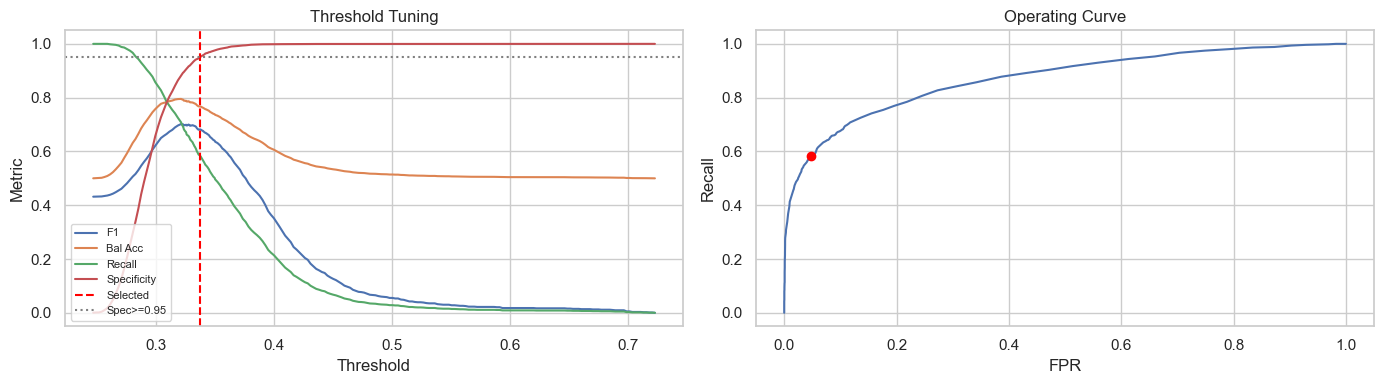

In [ ]:
# ── Threshold tuning ──────────────────────────────────────────────────────────
y_tune     = np.concatenate([np.zeros(len(test_normal_scores), dtype=int),
                             np.ones( len(test_defect_scores),  dtype=int)])
score_tune = np.concatenate([test_normal_scores, test_defect_scores])

candidates = np.unique(np.concatenate([
    np.percentile(train_scores, np.linspace(90.0, 99.9, 60)),
    np.linspace(score_tune.min(), score_tune.max(), 200),
]))

rows = []
for thr in candidates:
    pred = (score_tune > thr).astype(int)
    tp = int(((pred==1) & (y_tune==1)).sum()); tn = int(((pred==0) & (y_tune==0)).sum())
    fp = int(((pred==1) & (y_tune==0)).sum()); fn = int(((pred==0) & (y_tune==1)).sum())
    prec = tp/(tp+fp) if (tp+fp) else 0.; rec = tp/(tp+fn) if (tp+fn) else 0.
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.
    spec = tn/(tn+fp) if (tn+fp) else 0.
    rows.append(dict(threshold=float(thr), precision=prec, recall=rec,
                     f1=f1, specificity=spec, balanced_accuracy=0.5*(rec+spec),
                     fp=fp, fn=fn))

tuning_df = pd.DataFrame(rows)
constrained = tuning_df[tuning_df['specificity'] >= TARGET_SPECIFICITY]

if len(constrained) == 0:
    print('WARNING: no threshold meets specificity target; using best balanced accuracy.')
    best_row = tuning_df.sort_values(
        ['balanced_accuracy','recall','threshold'], ascending=[False,False,True]).iloc[0]
else:
    best_row = constrained.sort_values(
        ['recall','f1','threshold'], ascending=[False,False,True]).iloc[0]

threshold = float(best_row['threshold'])
print(f'Threshold: {threshold:.6f}')
print(f"Prec={best_row['precision']:.4f}  Rec={best_row['recall']:.4f}  "
      f"F1={best_row['f1']:.4f}  Spec={best_row['specificity']:.4f}  "
      f"FP={int(best_row['fp'])}  FN={int(best_row['fn'])}")
display(constrained.sort_values('recall', ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
for col, lab in [('f1','F1'),('balanced_accuracy','Bal Acc'),
                 ('recall','Recall'),('specificity','Specificity')]:
    ax.plot(tuning_df['threshold'], tuning_df[col], label=lab)
ax.axvline(threshold, color='red', ls='--', label='Selected')
ax.axhline(TARGET_SPECIFICITY, color='grey', ls=':', label=f'Spec>={TARGET_SPECIFICITY}')
ax.set(xlabel='Threshold', ylabel='Metric', title='Threshold Tuning')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(1 - tuning_df['specificity'], tuning_df['recall'])
ax.scatter([1-best_row['specificity']], [best_row['recall']], color='red', zorder=5)
ax.set(xlabel='FPR', ylabel='Recall', title='Operating Curve')
plt.tight_layout(); plt.show()

ROC-AUC: 0.8697
              precision    recall  f1-score   support

      normal       0.86      0.95      0.90      5000
     anomaly       0.82      0.58      0.68      1899

    accuracy                           0.85      6899
   macro avg       0.84      0.77      0.79      6899
weighted avg       0.85      0.85      0.84      6899



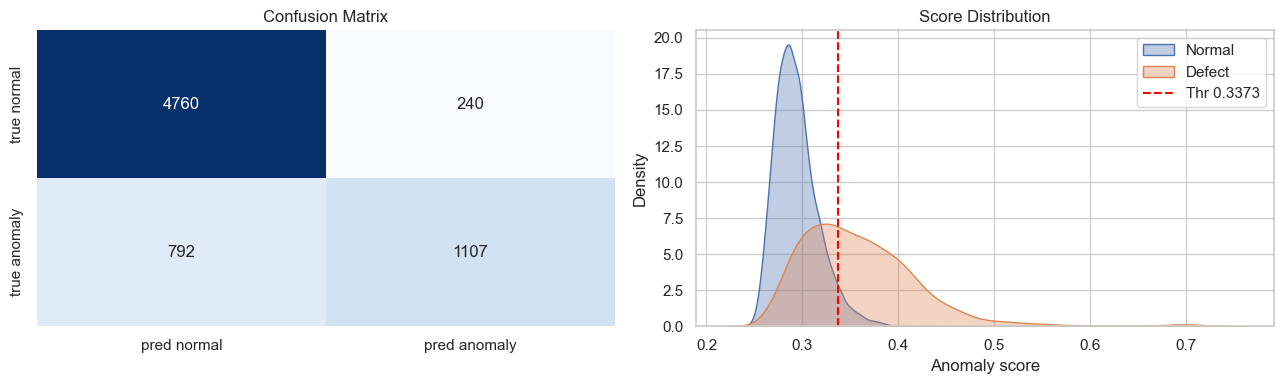


Per-defect-class recall:


,count,detected,recall,mean_score
failure_label,,,,
Center,250,57,0.228,0.318
Edge-Loc,250,89,0.356,0.333
Loc,250,107,0.428,0.341
Scratch,250,132,0.528,0.366
Edge-Ring,250,179,0.716,0.362
Random,250,199,0.796,0.370
Donut,250,201,0.804,0.401
Near-full,149,143,0.960,0.405


In [ ]:
# ── Final evaluation ──────────────────────────────────────────────────────────
y_true = np.concatenate([np.zeros(len(test_normal_scores), dtype=int),
                         np.ones( len(test_defect_scores),  dtype=int)])
scores = np.concatenate([test_normal_scores, test_defect_scores])
y_pred = (scores > threshold).astype(int)

roc_auc = float(roc_auc_score(y_true, scores))
print(f'ROC-AUC: {roc_auc:.4f}')
print(classification_report(y_true, y_pred, target_names=['normal','anomaly']))

cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred normal','pred anomaly'],
            yticklabels=['true normal','true anomaly'], ax=axes[0])
axes[0].set_title('Confusion Matrix')

sns.kdeplot(test_normal_scores, label='Normal', fill=True, alpha=0.35, ax=axes[1])
sns.kdeplot(test_defect_scores, label='Defect', fill=True, alpha=0.35, ax=axes[1])
axes[1].axvline(threshold, color='red', ls='--', label=f'Thr {threshold:.4f}')
axes[1].set(xlabel='Anomaly score', ylabel='Density', title='Score Distribution')
axes[1].legend()
plt.tight_layout(); plt.show()

# Per-class breakdown
tmp = test_defect_df.copy()
tmp['score']    = test_defect_scores
tmp['detected'] = (test_defect_scores > threshold).astype(int)
print('\nPer-defect-class recall:')
display(tmp.groupby('failure_label').agg(
    count=('detected','count'), detected=('detected','sum'),
    recall=('detected','mean'), mean_score=('score','mean'),
).round(3).sort_values('recall'))

In [ ]:
# ── Save artifacts ────────────────────────────────────────────────────────────
torch.save({
    'extractor_state_dict': extractor.state_dict(),
    'memory_bank': memory_bank.detach().cpu(),
    'threshold': threshold,
    'config': dict(backbone='wide_resnet50_2', image_size=IMAGE_SIZE, knn_k=KNN_K,
                   memory_bank_size=len(memory_bank), target_specificity=TARGET_SPECIFICITY),
}, MODEL_EXPORT_PATH)

with open(METRICS_EXPORT_PATH, 'w') as f:
    json.dump(dict(roc_auc=roc_auc, threshold=threshold, confusion_matrix=cm.tolist(),
                   n_test_normal=int(len(test_normal_scores)),
                   n_test_defect=int(len(test_defect_scores)),
                   specificity=float(best_row['specificity']),
                   recall=float(best_row['recall']),
                   precision=float(best_row['precision']),
                   f1=float(best_row['f1'])), f, indent=2)

print('Saved model ->', MODEL_EXPORT_PATH)
print('Saved metrics ->', METRICS_EXPORT_PATH)


Saved model -> ../artifacts/x64/patchcore_improved\patchcore_model.pt
Saved metrics -> ../artifacts/x64/patchcore_improved\evaluation_metrics.json


## Memory budget — RTX 4060 Laptop (8 GB VRAM)

| Stage | Peak VRAM |
|---|---|
| WRN-50-2 weights (fp32) | ~270 MB |
| Feature extraction batch=32, img=64 | ~350 MB |
| Coreset pool 150k × 1536 fp32 | ~925 MB |
| Memory bank 30k × 1536 fp32 | ~185 MB |
| Scoring chunk=256 vs bank | ~150 MB |
| **Estimated peak (coreset step)** | **~1.5 GB** |

If you still hit OOM during the coreset step, reduce `CORESET_POOL` to `80_000`.

## Tuning knobs

| Knob | Effect |
|---|---|
| `IMAGE_SIZE=96` | Better spatial detail, ~2× slower |
| `KNN_K=5` | Smoother scores, marginal AUC change |
| `MEMORY_BANK_FINAL=50_000` | Higher quality bank if VRAM allows |
| `TARGET_SPECIFICITY=0.90` | More recall, more false alarms |